# Model Training and Evaluation

This notebook is the **third stage** in the machine learning pipeline and builds 
directly upon the preprocessed data from the previous notebook. Our goal here is 
to **train, tune, and evaluate machine learning models** to predict whether a 
diabetic patient will be readmitted within 30 days of discharge.

---

### Notebook Objective

In this notebook, we aim to:
- Load the preprocessed train/validation/test sets
- Establish a baseline model to benchmark against
- Train and tune multiple machine learning models
- Evaluate models using appropriate metrics for imbalanced data
- Select the best performing model for explainability analysis

---

### Why This Matters

Model selection and evaluation are critical steps in any ML pipeline. A poorly 
evaluated model can appear to perform well while learning nothing useful — 
especially on imbalanced datasets like this one where a naive model can achieve 
91% accuracy by always predicting the majority class. Rigorous evaluation ensures 
our model is genuinely learning signal, not exploiting class imbalance.

---

### Evaluation Strategy

Since the positive class (readmitted within 30 days) represents only ~9% of the 
data, accuracy is not a meaningful metric. We will prioritize:
- **F1-score** — balances precision and recall
- **ROC-AUC** — measures discriminative ability across thresholds
- **Precision/Recall** — to understand the tradeoff between false positives and false negatives

---

### Next Steps in the Workflow

The best model selected here will be used in the following notebook:
- `04_model_explainability.ipynb`

## Section 1 - Imports and Data Loading

In [3]:
# Importing the libaries needed 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


# Setting the plot style
sns.set(style='whitegrid')

# Setting a random state for reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [4]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [5]:
# Importing the custom functions, reloading the module to ensure the latest version is used
import importlib
import utils.functions as f

importlib.reload(f)

<module 'utils.functions' from 'c:\\Users\\Elias\\Documents\\Diabetes-readmission-ml-pipeline-main\\Diabetes-readmission-ml-pipeline-main\\utils\\functions.py'>

In [6]:
# Loading the processed data, splitted into training, validation, and test sets
# Training
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()

# Validation
X_val = pd.read_csv('../data/processed/X_val.csv', index_col=0)
y_val = pd.read_csv('../data/processed/y_val.csv', index_col=0).squeeze()

# Test
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

In [7]:
# Verification
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"NaN values: {X_train.isnull().sum().sum()}")
print(f"Target distribution:\n{y_train.value_counts(normalize=True)}")

X_train: (41955, 38), y_train: (41955,)
X_val: (13993, 38), y_val: (13993,)
X_test: (13981, 38), y_test: (13981,)
NaN values: 0
Target distribution:
readmitted
0    0.910237
1    0.089763
Name: proportion, dtype: float64


## Section 2 - Baseline Model
For this section, we are creating a baseline model, or dummy classifier, that will serveas a benchmark for the rest of the models. 

### 2.1 - Model Training

In [8]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)
y_prob = baseline.predict_proba(X_val)[:, 1]

baseline_metrics = f.evaluate_model(y_val, y_pred, y_prob)

print("Baseline Model Performance:")
print(baseline_metrics)

Baseline Model Performance:
{'accuracy': 0.9104552276138069, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.5}


### 2.2 - Baseline Results

The dummy classifier achieves 91% accuracy by predicting the majority class (not 
readmitted) for every patient. This confirms that accuracy is a misleading metric 
on this imbalanced dataset, a model that never identifies a single readmission 
case scores 91%.

Our real models must demonstrate meaningful F1-score and ROC-AUC > 0.5 to be 
considered useful. These are the metrics we will prioritize going forward.

## Section 3 - Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)
y_prob_lr = lr_model.predict_proba(X_val)[:, 1]

lr_metrics = f.evaluate_model(y_val, y_pred_lr, y_prob_lr)

print(f"Logistic Regression Metrics: {lr_metrics}")

Logistic Regression Metrics: {'accuracy': 0.7528764382191095, 'f1': 0.32408131352619235, 'precision': 0.21460005177323324, 'recall': 0.6616121308858739, 'roc_auc': 0.7829883945720224}


### 3.2 - Logistic Regression Results

Logistic Regression with `class_weight='balanced'` produces the following results on the validation set:

| Metric | Value | Benchmark (literature)* |
|--------|-------|----------------------|
| ROC-AUC | 0.783 | 0.642 |
| Recall | 0.662 | — |
| F1 | 0.324 | — |
| Precision | 0.215 | — |
| Accuracy | 0.753 | — |

Our ROC-AUC of 0.783 exceeds the benchmark of 0.642 reported in recent literature, 
likely due to our more careful feature engineering and preprocessing pipeline.

The low F1 score (0.32) is expected on this dataset — it is a direct consequence 
of the class imbalance (9% positive class). The model prioritizes recall over 
precision, catching 66% of actual readmissions at the cost of more false positives. 
In a clinical context this tradeoff is acceptable, missing a readmission is more 
costly than an unnecessary follow-up call.

Accuracy dropped from 91% (baseline) to 75%, this is a feature, not a bug. The 
model is now genuinely attempting to identify readmissions rather than exploiting 
the majority class.

\* Emi-Johnson OG, Nkrumah KJ. "Predicting 30-Day Hospital Readmission in Patients 
With Diabetes Using Machine Learning on Electronic Health Record Data." 
Cureus. 2025 Apr 17;17(4):e82437. doi: 10.7759/cureus.82437. PMC12085305.


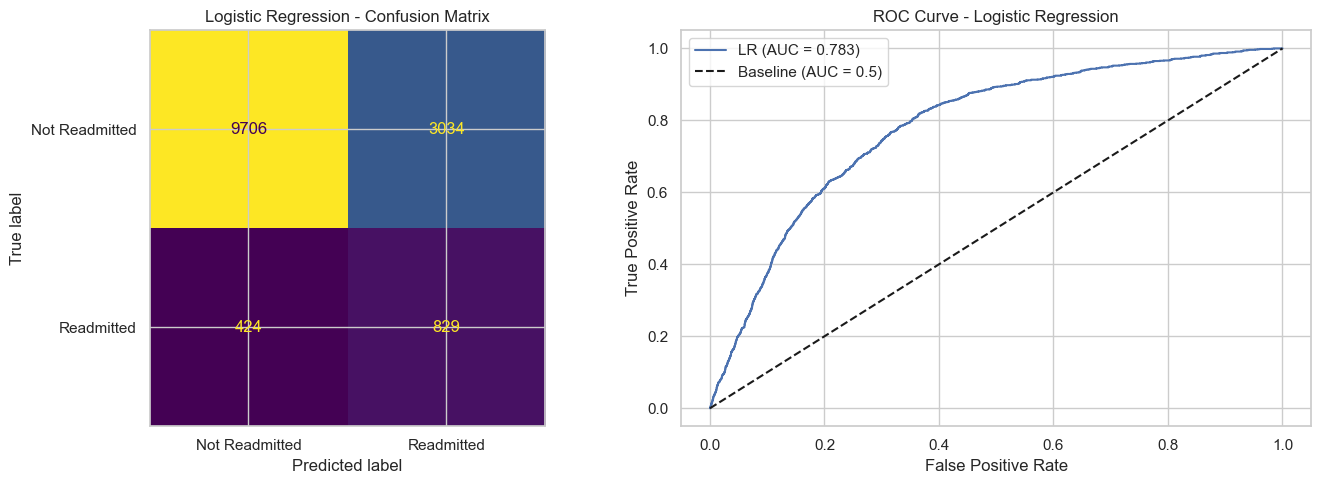

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression - Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_lr)
axes[1].plot(fpr, tpr, label=f'LR (AUC = {lr_metrics["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

The confusion matrix shows the model correctly identifies 829 out of 1253 actual 
readmissions, missing 424. While the 3034 false positives are high, this is an 
expected tradeoff when prioritizing recall, in a clinical context, an unnecessary 
follow-up is far less costly than a missed readmission. The ROC curve confirms 
strong discriminative ability with an AUC of 0.783, well above the random baseline 
of 0.5, with a steep initial rise indicating the model ranks true positives highly 
even at low false positive rates.

## Section 4 - Random Forest

### 4.1 - Training and Evaluating the Model

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced_subsample', 
    random_state=RANDOM_STATE,
    n_estimators=100,
    min_samples_leaf=5,
    max_depth=10
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

rf_metrics = f.evaluate_model(y_val, y_pred_rf, y_prob_rf)
print(f"Random Forest Metrics: {rf_metrics}")

Random Forest Metrics: {'accuracy': 0.7742442649896377, 'f1': 0.3640024159452386, 'precision': 0.24340333871836295, 'recall': 0.7214684756584198, 'roc_auc': 0.8072457185956218}


### 4.2 - Random Forest Results

Random Forest with `class_weight='balanced_subsample'` and `n_estimators=100` 
produces the following results on the validation set:

| Metric | Value | LR Comparison |
|--------|-------|--------------|
| ROC-AUC | 0.807 | +0.024 vs LR |
| Recall | 0.721 | +0.059 vs LR |
| F1 | 0.364 | +0.040 vs LR |
| Precision | 0.243 | +0.028 vs LR |
| Accuracy | 0.774 | +0.021 vs LR |

Random Forest outperforms Logistic Regression across all metrics. The improvement 
in recall is particularly notable, the model now catches 72% of actual readmissions 
compared to 66% with LR.

Note: Initial training with `class_weight='balanced'` resulted in near-zero recall 
(0.009), confirming that hyperparameter choices matter significantly even for 
well-established algorithms.

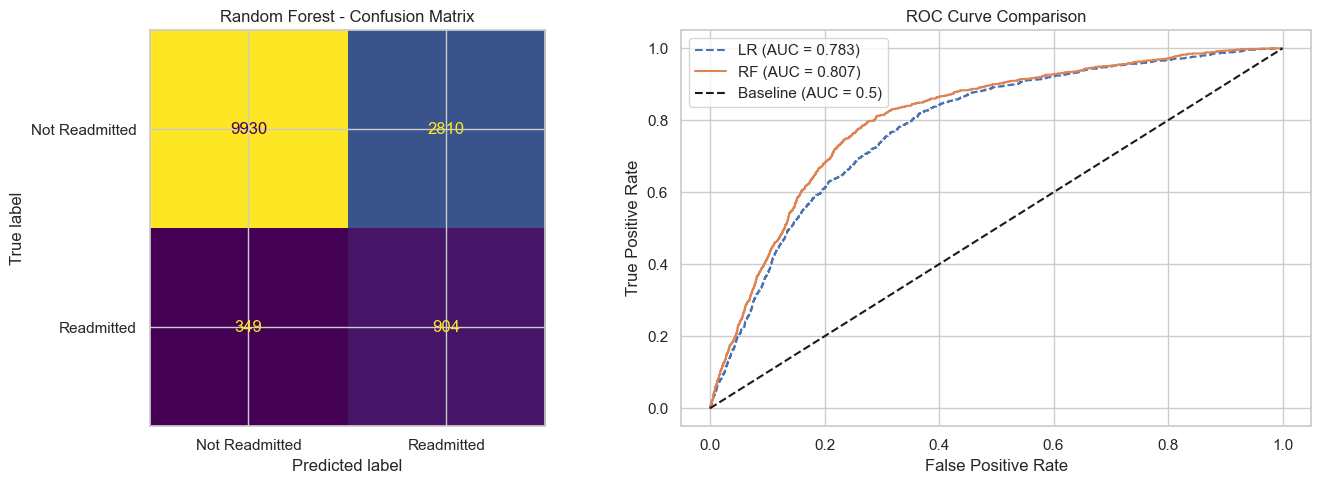

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest - Confusion Matrix')

# ROC Curve - comparing LR and RF
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr)

axes[1].plot(fpr_lr, tpr_lr, label=f'LR (AUC = {lr_metrics["roc_auc"]:.3f})', linestyle='--')
axes[1].plot(fpr_rf, tpr_rf, label=f'RF (AUC = {rf_metrics["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

The confusion matrix shows Random Forest correctly identifies 904 out of 1253 actual 
readmissions, missing only 349, a clear improvement over Logistic Regression which 
missed 424. False positives increased slightly to 2810, reflecting the higher recall 
tradeoff. The ROC curve comparison confirms Random Forest consistently outperforms 
Logistic Regression across all thresholds, with the RF curve sitting above the LR 
curve throughout and particularly in the clinically important low false positive rate 
region below 0.2.

## Section 5 - XGBoost

### 5.1 - Training and Evaluating the Model

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

xgb_metrics = f.evaluate_model(y_val, y_pred_xgb, y_prob_xgb)
print(f"XGBoost Metrics: {xgb_metrics}")

XGBoost Metrics: {'accuracy': 0.7539484027728149, 'f1': 0.3558465855940131, 'precision': 0.23240469208211142, 'recall': 0.7589784517158819, 'roc_auc': 0.807042031620187}


### 5.2 - XGBoost Results

XGBoost with `scale_pos_weight` set to the inverse class ratio produces the 
following results on the validation set:

| Metric | Value | LR Comparison | RF Comparison |
|--------|-------|--------------|--------------|
| ROC-AUC | 0.807 | +0.024 vs LR | ~0.000 vs RF |
| Recall | 0.759 | +0.097 vs LR | +0.038 vs RF |
| F1 | 0.356 | +0.032 vs LR | -0.008 vs RF |
| Precision | 0.232 | +0.017 vs LR | -0.011 vs RF |
| Accuracy | 0.754 | +0.001 vs LR | -0.020 vs RF |

XGBoost achieves the highest recall of all three models, catching 76% of actual 
readmissions. ROC-AUC matches Random Forest closely at 0.807. The model was tuned 
with `learning_rate=0.05`, `subsample=0.8`, and `colsample_bytree=0.8` for 
regularization. Higher learning rates degraded performance, confirming that slower, 
more conservative learning better suits this dataset.

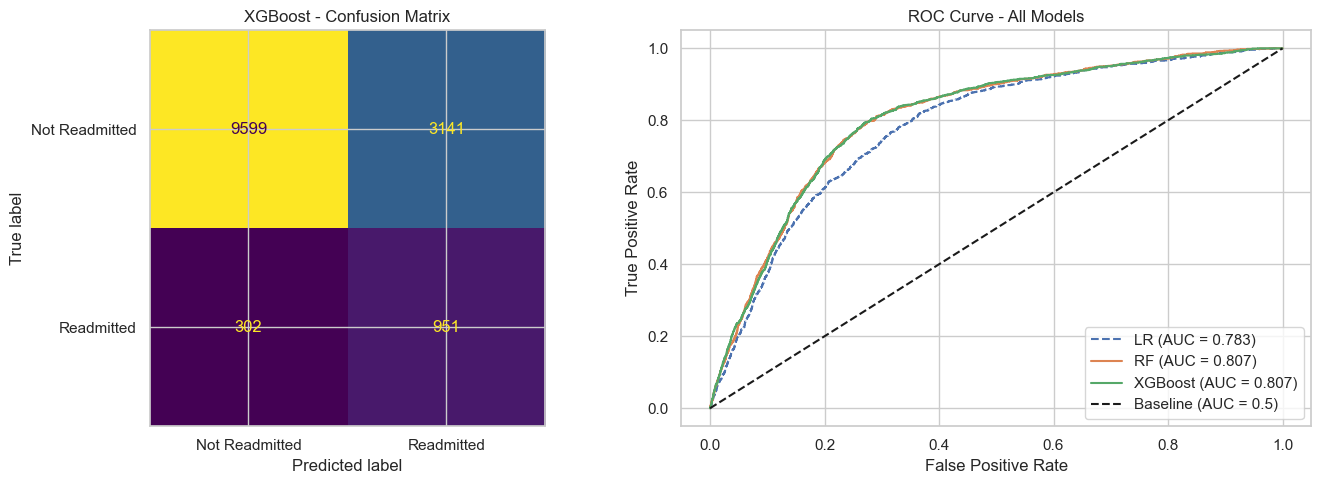

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('XGBoost - Confusion Matrix')

# ROC Curve - all three models
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb)

axes[1].plot(fpr_lr, tpr_lr, label=f'LR (AUC = {lr_metrics["roc_auc"]:.3f})', linestyle='--')
axes[1].plot(fpr_rf, tpr_rf, label=f'RF (AUC = {rf_metrics["roc_auc"]:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_metrics["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - All Models')
axes[1].legend()

plt.tight_layout()
plt.show()

XGBoost catches 951 out of 1253 actual readmissions the highest true positive count 
of all three models and missing only 302. False positives are 3141, slightly higher 
than Random Forest, reflecting the higher recall tradeoff. The ROC curve shows RF 
and XGBoost almost completely overlapping at AUC 0.807, both clearly outperforming 
Logistic Regression. The separation between ensemble models and LR is most pronounced 
in the low false positive rate region below 0.2, which is the most clinically 
relevant operating range.

## Section 6 - Evaluation

### 6.1 - Comparison and Model Selection
We compare the results for the models, and choose the best one. We will use the best model to evaluate our test data on. 

#### 6.1.1 - Comparing and Choosing the Best Model

In [25]:
joint_metrics =({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
})

print("Model Performance Comparison:")
print(pd.DataFrame(joint_metrics).T.round(3))

Model Performance Comparison:
                     accuracy     f1  precision  recall  roc_auc
Logistic Regression     0.753  0.324      0.215   0.662    0.783
Random Forest           0.774  0.364      0.243   0.721    0.807
XGBoost                 0.754  0.356      0.232   0.759    0.807


All three models were evaluated across accuracy, F1, precision, recall, and ROC-AUC. Accuracy is excluded as a meaningful metric given the class imbalance since a model predicting the majority class achieves 91% by default.
Random Forest and XGBoost both achieve a ROC-AUC of 0.807, effectively identical. 

The deciding factor is recall. Since this is a clinical problem, false negatives carry the highest cost, a missed readmission is worse than an unnecessary follow-up. 
XGBoost achieves the highest recall at 0.759, compared to 0.721 for Random Forest. The tradeoff is a slightly lower F1 and precision, but that is an acceptable exchange given the priority. XGBoost is selected as the final model. Thus,

**The Chosen model: XGBoost**

#### 6.1.2 - Performing a Gridsearch on the Chosen Model

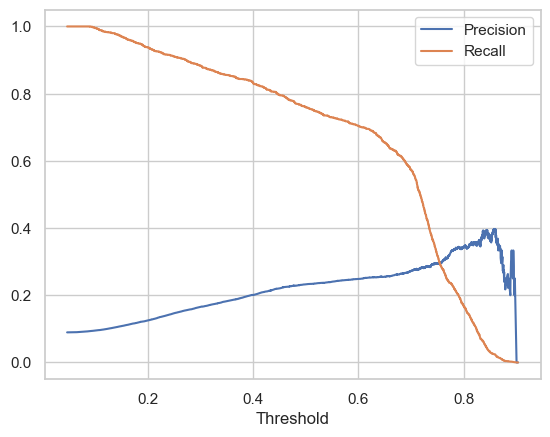

In [26]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_xgb)

# Plot to find a good tradeoff
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

From our gridsearch we can conclude that the precision is relativley low at all thresholds, and from 0.4 we do not get any real imporvment. The Recall however is relativley high still at threshold = 0.4, which would be a good trade-off between catching the false negatives while not having as many false positives. Thus,

**Chosen Threshold: 0.4**

### 6.2 - Applying the Test Data to the Chosen Model

In [28]:
# Applying the best model (XGBoost) to the test set
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= 0.4).astype(int)  # applying chosen threshold

# Evaluating the test set performance
test_metrics = f.evaluate_model(y_test, y_pred_test, y_prob_test)
print("Test Set Performance of XGBoost:")
print(test_metrics)

Test Set Performance of XGBoost:
{'accuracy': 0.6825692010585795, 'f1': 0.31342821782178215, 'precision': 0.19447110769821463, 'recall': 0.8071713147410359, 'roc_auc': 0.7974160250401819}


### 6.3 - Conclusions

Three models were trained and evaluated on a heavily imbalanced dataset where 
the positive class, readmission within 30 days, represents only 9% of cases. 
XGBoost was selected as the final model based on its superior recall, the metric 
that matters most in a clinical context where missing a readmission is costlier 
than a false alarm.

**Final model:** XGBoost with a decision threshold of 0.4  
**Test set ROC-AUC:** 0.797  
**Test set Recall:** 0.807  

At this threshold, the model correctly identifies 8 out of 10 patients at risk 
of readmission, exceeding the literature benchmark of 0.642 ROC-AUC.

### Limitations

No formal hyperparameter search was performed but parameters were manually tuned 
against the validation set. The decision threshold was selected by inspection 
rather than optimised against a clinical cost function. Dropping individual 
medication columns in favour of `diabetesMed` was a deliberate simplification 
that may have lost signal, particularly for insulin. `visit_frequency` is a 
dataset-level proxy, not a true temporal visit history.

### Next Steps

SHAP-based explainability analysis to identify which features drive predictions 
and in which direction.